# Multi-Terrain Evaluation Analysis

This notebook loads all CSV evaluation files for a selected approach from an experiment folder, computes metrics per terrain, and computes pooled metrics across all terrains.

Expected filename pattern:

```text
{approach}_{terrain}_{disturbance_condition}.csv
```

Example:

```text
pact_rough_payload.csv
pos_stairs_push.csv
tau_plane_none.csv
```

Set `EXP_FOLDER`, `APPROACH`, and optionally `DISTURBANCE_CONDITION` in the configuration cell below.


In [1]:
import os
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration

In [2]:
# --- User settings ---
EXP_FOLDER = "pact_origjointrand_strongtau/"
APPROACH = "go1_pact"

# Set to None to load every disturbance condition for this approach.
# Otherwise use strings like "none", "payload", "push", etc.
DISTURBANCE_CONDITION = None

# Optional output directory for result tables
RESULTS_DIR = Path(EXP_FOLDER) / "analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Default target used for height tracking.
BASE_HEIGHT_TARGET = 0.30

# Optional constants used only for limit violation metrics.
# Expected shapes:
#   JOINT_LIMITS: [2, num_dofs], where row 0 is lower and row 1 is upper
#   JOINT_TORQUE_LIMITS: scalar or [num_dofs]
JOINT_LIMITS = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

EPS = 1e-8

EXCLUDE_DIRS = ["analysis_results"]

NUM_WORKERS = 20

## Loading utilities

In [3]:
def string_to_array(array_string):
    """Convert stringified list/array columns from the logger into Python lists."""
    if isinstance(array_string, str):
        try:
            return ast.literal_eval(array_string)
        except (ValueError, SyntaxError):
            return array_string
    return array_string


ARRAY_COLUMNS = [
    "base_cmd",
    "base_pose",
    "base_rpy",
    "dof_pose",
    "base_lin_vel",
    "base_ang_vel",
    "dof_vel",
    "proj_grav",
    "feet_pos",
    "tau_act",
    "grf",
    "q_des",
    "tau_ff",
    "tau_pd",
    "payload",
    "com_shift",
    "rand_push",
    "rand_wrench",
]


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {col: string_to_array for col in columns}


def parse_eval_filename(path, approach):
    """
    Parse filenames of the form:
        {approach}_{terrain}_{disturbance_condition}.csv

    This assumes the terrain token comes immediately after the approach token.
    Everything after the terrain token is treated as the disturbance condition.
    """
    stem = Path(path).stem

    prefix = f"{approach}_"
    if not stem.startswith(prefix):
        return None

    remainder = stem[len(prefix):]
    parts = remainder.split("_")

    if len(parts) < 2:
        return None

    terrain = parts[0]
    disturbance_condition = "_".join(parts[1:])

    return {
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "path": Path(path),
    }


def find_eval_files(exp_folder, approach, disturbance_condition=None):
    exp_folder = Path(exp_folder)

    records = []
    for path in sorted(exp_folder.rglob(f"{approach}_*.csv")):
        info = parse_eval_filename(path, approach)
        if info is None:
            continue

        # Skip blacklisted subdirectories
        if EXCLUDE_DIRS:
            rel_parts = path.relative_to(exp_folder).parts
            if any(part in EXCLUDE_DIRS for part in rel_parts):
                continue

        if disturbance_condition is not None:
            if info["disturbance_condition"] != disturbance_condition:
                continue

        records.append(info)

    return pd.DataFrame(records)


def load_eval_csv(path):
    """Load one evaluation CSV with logger array columns converted."""
    return pd.read_csv(path, converters=get_csv_converters())


def load_eval_dataset(file_table):
    """
    Load all files in file_table and concatenate them into one dataframe.

    Adds:
        approach
        terrain
        disturbance_condition
        source_file
    """
    dfs = []

    for _, row in file_table.iterrows():
        df = load_eval_csv(row["path"])

        df["approach"] = row["approach"]
        df["terrain"] = row["terrain"]
        df["disturbance_condition"] = row["disturbance_condition"]
        df["source_file"] = str(row["path"])

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)


def _load_one_eval_file(row):
    df = load_eval_csv(row["path"])

    df["approach"] = row["approach"]
    df["terrain"] = row["terrain"]
    df["disturbance_condition"] = row["disturbance_condition"]
    df["source_file"] = str(row["path"])

    return df

def load_eval_dataset_parallel(file_table, max_workers=10):
    rows = [row for _, row in file_table.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(_load_one_eval_file, rows))

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

In [4]:
file_table = find_eval_files(
    EXP_FOLDER,
    APPROACH,
    disturbance_condition=DISTURBANCE_CONDITION,
)

file_table


,approach,terrain,disturbance_condition,path
0,go1_pact,discrete,none,pact_origjointrand_strongtau/no_disturbance/go...
1,go1_pact,plane,none,pact_origjointrand_strongtau/no_disturbance/go...
2,go1_pact,rough,none,pact_origjointrand_strongtau/no_disturbance/go...
3,go1_pact,slope,none,pact_origjointrand_strongtau/no_disturbance/go...
4,go1_pact,stairs,none,pact_origjointrand_strongtau/no_disturbance/go...
5,go1_pact,wave,none,pact_origjointrand_strongtau/no_disturbance/go...
6,go1_pact,discrete,payload,pact_origjointrand_strongtau/payload_disturban...
7,go1_pact,plane,payload,pact_origjointrand_strongtau/payload_disturban...
8,go1_pact,rough,payload,pact_origjointrand_strongtau/payload_disturban...
9,go1_pact,slope,payload,pact_origjointrand_strongtau/payload_disturban...


In [5]:
df_all = load_eval_dataset_parallel(file_table, max_workers=NUM_WORKERS)

print(f"Loaded {len(file_table)} files")
print(f"Loaded {len(df_all):,} rows")
print("Terrains:", sorted(df_all["terrain"].unique()))
print("Disturbance conditions:", sorted(df_all["disturbance_condition"].unique()))

df_all.head()


Loaded 18 files
Loaded 7,200,000 rows
Terrains: ['discrete', 'plane', 'rough', 'slope', 'stairs', 'wave']
Disturbance conditions: ['none', 'payload', 'push']


,Unnamed: 0,base_cmd,base_pose,base_rpy,dof_pose,base_lin_vel,base_ang_vel,dof_vel,proj_grav,feet_pos,...,tau_pd,failure,payload,com_shift,rand_push,rand_wrench,approach,terrain,disturbance_condition,source_file
0,0,"[-0.0960875153541565, -0.26534610986709595, 1....","[3.8359293937683105, 3.892320156097412, 0.3293...","[0.0017937096999958158, 0.0020395179744809866,...","[-0.20677578449249268, 0.5784812569618225, -1....","[-0.4284757971763611, -0.187883198261261, -0.5...","[0.09863437712192535, -0.002363014966249466, -...","[2.2363717555999756, 4.791721343994141, -5.421...","[0.0020395165774971247, -0.0017937046941369772...","[[4.055400848388672, 3.6993234157562256, 0.021...",...,"[2.921452045440674, 5.8958282470703125, -3.119...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_origjointrand_strongtau/no_disturbance/go...
1,1,"[0.06778740882873535, 0.4088113307952881, 0.71...","[19.76618766784668, 4.427699565887451, 0.33239...","[0.026588184759020805, 0.0051502357237041, 0.0...","[0.1229766234755516, 1.053291916847229, -1.418...","[-0.24345825612545013, -0.2631070613861084, -0...","[1.912400245666504, 0.2704044580459595, 0.2390...","[-2.733367919921875, -0.4573237895965576, -2.7...","[0.005150212906301022, -0.026584699749946594, ...","[[19.84393310546875, 4.347551345825195, 0.0178...",...,"[-5.546290397644043, -6.685992240905762, -2.49...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_origjointrand_strongtau/no_disturbance/go...
2,2,"[-0.07134497165679932, 0.9602271318435669, 0.1...","[27.54875946044922, 3.6689319610595703, 0.3372...","[-0.006924579385668039, 0.0020765599329024553,...","[0.006890611257404089, 0.9994326233863831, -1....","[0.3481942415237427, 0.20531271398067474, -0.2...","[-0.6385230422019958, 0.22338184714317322, -0....","[-1.5858358144760132, -3.287712812423706, -3.0...","[0.0020765585359185934, 0.006924508139491081, ...","[[27.631912231445312, 3.542187213897705, 0.022...",...,"[-3.087484836578369, -5.673943519592285, -3.75...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_origjointrand_strongtau/no_disturbance/go...
3,3,"[0.08069193363189697, 0.3022540807723999, 0.27...","[27.905385971069336, 3.6168339252471924, 0.336...","[-0.02475568652153015, 0.0018350668251514435, ...","[-0.2465570718050003, 0.9572277665138245, -1.2...","[0.2727620601654053, -0.43004530668258667, -0....","[-1.706996202468872, 0.2685871720314026, 0.327...","[3.5547242164611816, -1.7755262851715088, -5.4...","[0.0018350658938288689, 0.024753117933869362, ...","[[27.989585876464844, 3.406700611114502, 0.047...",...,"[3.831779718399048, -4.7526421546936035, -5.26...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_origjointrand_strongtau/no_disturbance/go...
4,4,"[0.18676280975341797, -0.8427570462226868, 0.5...","[4.175819396972656, 4.0778021812438965, 0.3332...","[0.0055605038069188595, 0.009475183673202991, ...","[-0.1938047856092453, 0.9949651956558228, -1.6...","[0.47304490208625793, -0.04357854649424553, -0...","[0.3529781699180603, 0.4884859323501587, -0.33...","[2.5465502738952637, -2.7381298542022705, 4.15...","[0.00947504211217165, -0.0055602253414690495, ...","[[4.307865619659424, 3.897599935531616, 0.0644...",...,"[3.930835008621216, -0.7447024583816528, 2.296...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,pact_origjointrand_strongtau/no_disturbance/go...


## Metric utilities

In [6]:
def as_array(df, column, valid_mask=None):
    """Convert a dataframe column of list-like entries into a numpy array."""
    if column not in df.columns:
        return None

    series = df[column]
    if valid_mask is not None:
        series = series.loc[valid_mask]

    if len(series) == 0:
        return None

    return np.asarray(series.to_list())


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))


def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))


def rmse(x):
    x = np.asarray(x)
    return float(np.sqrt(np.nanmean(np.square(x))))


def mae(x):
    x = np.asarray(x)
    return float(np.nanmean(np.abs(x)))


def mean_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanmean(np.linalg.norm(x, axis=axis, ord=1)))


def std_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanstd(np.linalg.norm(x, axis=axis, ord=1)))


def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [7]:
def compute_eval_metrics(
    df,
    approach='pact',
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """
    Compute scalar evaluation metrics for one dataframe.

    Failed rows are excluded from continuous metrics but counted in failure statistics.
    """
    metrics = {}

    use_pact_metrics = (
        approach is not None
        and any(k.lower() in approach.lower() for k in pact_metric_approaches)
    )

    n_total = len(df)
    failure = df["failure"].astype(float).to_numpy() if "failure" in df.columns else np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate"] = float(failure.mean()) if n_total > 0 else np.nan

    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)

    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)

    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)

    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)

    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    # Joint tracking
    if q_actions is not None and q_obs is not None:
        dof_errors = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(dof_errors)
        metrics["dof_tracking_mae"] = mae(dof_errors)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)

        if joint_limits is not None:
            joint_limits = np.asarray(joint_limits)
            joint_pred_limits_error = -(q_actions - joint_limits[0, :]).clip(max=0.0)
            joint_pred_limits_error += (q_actions - joint_limits[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(joint_pred_limits_error))

    # Command tracking
    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_cmd_errors = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_cmd_errors = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:, None]), axis=1)

        metrics["lin_cmd_rmse"] = rmse(lin_cmd_errors)
        metrics["lin_cmd_mae"] = mae(lin_cmd_errors)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_cmd_errors))))

        metrics["ang_cmd_rmse"] = rmse(ang_cmd_errors)
        metrics["ang_cmd_mae"] = mae(ang_cmd_errors)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_cmd_errors))))

        metrics["total_cmd_rmse"] = rmse(cmd_errs)
        metrics["total_cmd_mae"] = mae(cmd_errs)

    # Height / orientation / unwanted velocity
    if base_pose is not None:
        height_errors = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(height_errors)
        metrics["height_mae"] = mae(height_errors)

    if proj_grav is not None:
        orientation_norm = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orientation_norm)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orientation_norm)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        ang_vel_rp_norm = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        total_unwanted_vel = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        total_unwanted_norm = np.linalg.norm(total_unwanted_vel, axis=1, ord=1)

        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(ang_vel_rp_norm)
        metrics["ang_vel_rp_norm_std"] = safe_std(ang_vel_rp_norm)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(total_unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(total_unwanted_norm)

    # Torque / force / power
    if q_vel is not None and q_tau is not None:
        joint_power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(joint_power)
        metrics["joint_power_norm_std"] = std_norm(joint_power)

    if grfs is not None:
        # Handle either [N, 4, 3] or flattened [N, 12].
        grf_flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(grf_flat)
        metrics["grf_norm_std"] = std_norm(grf_flat)

    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)

    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau_cmd = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau_cmd)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau_cmd)

        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))

        if joint_torque_limits is not None:
            joint_torque_limits = np.asarray(joint_torque_limits)
            violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
            violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    # FF/PD power interaction metrics
    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel

        dot = np.sum(ff_power * pd_power, axis=1)
        ff_power_norm = np.linalg.norm(ff_power, axis=1)
        pd_power_norm = np.linalg.norm(pd_power, axis=1)

        cosine_sim = dot / ((ff_power_norm * pd_power_norm) + eps)

        metrics["ff_power_norm_mean"] = safe_mean(ff_power_norm)
        metrics["pd_power_norm_mean"] = safe_mean(pd_power_norm)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pd_power_norm) / (np.mean(ff_power_norm) + eps))
        metrics["power_alignment_mean"] = safe_mean(cosine_sim)
        metrics["power_alignment_std"] = safe_std(cosine_sim)

        neg_dot = np.maximum(-dot, 0.0)
        metrics["fraction_antagonistic_energy"] = float(np.sum(neg_dot) / (np.sum(np.abs(dot)) + eps))

        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))

    return metrics


## Compute per-terrain and all-terrain metrics

In [8]:
def summarize_by_terrain(df_all):
    rows = []

    group_cols = ["approach", "terrain", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, terrain, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": terrain,
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_all_terrains(df_all):
    rows = []

    group_cols = ["approach", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": "ALL",
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


per_terrain_results = summarize_by_terrain(df_all)
all_terrain_results = summarize_all_terrains(df_all)
combined_results = pd.concat([per_terrain_results, all_terrain_results], ignore_index=True)

combined_results


,approach,terrain,disturbance_condition,num_rows_total,num_rows_valid,num_failures,failure_rate,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,...,pd_tau_ratio_mean,pd_to_ff_tau_norm_ratio,joint_torque_limit_violation_mean,ff_power_norm_mean,pd_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,power_alignment_std,fraction_antagonistic_energy,internal_power_cancellation
0,go1_pact,discrete,none,400000,400000,0,0.000000,0.134366,0.100719,9.654503,...,0.516239,1.082222,0.000243,26.521292,33.081627,1.247361,0.794828,0.220865,0.001741,0.034027
1,go1_pact,discrete,payload,400000,399926,74,0.000185,0.163097,0.118815,9.932928,...,0.515430,1.092332,0.017198,33.210105,40.461866,1.218360,0.788715,0.237130,0.003794,0.042576
2,go1_pact,discrete,push,400000,399956,44,0.000110,0.153932,0.111644,9.612724,...,0.525968,1.134529,0.012546,37.662174,46.577632,1.236722,0.790662,0.230665,0.005459,0.042308
3,go1_pact,plane,none,400000,400000,0,0.000000,0.131072,0.099272,9.559540,...,0.511611,1.058409,0.000025,25.331418,31.053563,1.225891,0.804270,0.210836,0.001417,0.031348
4,go1_pact,plane,payload,400000,399958,42,0.000105,0.158113,0.116098,9.845137,...,0.509898,1.065623,0.014778,30.926861,36.819333,1.190529,0.798658,0.230110,0.002621,0.039362
5,go1_pact,plane,push,400000,399989,11,0.000028,0.147124,0.108672,9.534264,...,0.521669,1.109212,0.005266,34.479884,41.441233,1.201896,0.800681,0.218490,0.002891,0.038406
6,go1_pact,rough,none,400000,400000,0,0.000000,0.134659,0.101104,9.647502,...,0.517219,1.086433,0.000047,26.719879,33.090423,1.238420,0.795511,0.218383,0.001607,0.034550
7,go1_pact,rough,payload,400000,399945,55,0.000138,0.163254,0.119686,9.844532,...,0.516644,1.094719,0.012137,34.591760,41.786033,1.207976,0.792941,0.233988,0.006781,0.042419
8,go1_pact,rough,push,400000,399974,26,0.000065,0.156199,0.113821,9.623460,...,0.526601,1.136734,0.011336,38.540964,46.302828,1.201393,0.787898,0.232073,0.004220,0.042937
9,go1_pact,slope,none,400000,400000,0,0.000000,0.136266,0.101522,9.851300,...,0.515329,1.078454,0.000145,27.728781,34.243121,1.234931,0.793101,0.223226,0.001730,0.035514


In [9]:
# Save result tables
per_terrain_path = RESULTS_DIR / f"{APPROACH}_per_terrain_results.csv"
all_terrain_path = RESULTS_DIR / f"{APPROACH}_all_terrain_results.csv"
combined_path = RESULTS_DIR / f"{APPROACH}_combined_results.csv"

per_terrain_results.to_csv(per_terrain_path, index=False)
all_terrain_results.to_csv(all_terrain_path, index=False)
combined_results.to_csv(combined_path, index=False)

print("Saved:")
print(per_terrain_path)
print(all_terrain_path)
print(combined_path)


Saved:
pact_origjointrand_strongtau/analysis_results/go1_pact_per_terrain_results.csv
pact_origjointrand_strongtau/analysis_results/go1_pact_all_terrain_results.csv
pact_origjointrand_strongtau/analysis_results/go1_pact_combined_results.csv


## Compact result views

In [10]:
# Choose the metrics you care about most for a compact table.
summary_cols = [
    "approach",
    "terrain",
    "disturbance_condition",
    "num_failures",
    "height_mae",
    "lin_cmd_mae",
    "ang_cmd_mae",
    "projected_gravity_rp_norm_mean",
    "z_vel_mae",
    "ang_vel_rp_norm_mean",
    "dof_tracking_mae",
    "joint_power_norm_mean",
    "pd_to_ff_power_ratio",
    "power_alignment_mean",
    "fraction_antagonistic_energy",
    "internal_power_cancellation",
    "ff_tau_norm_mean",
    "pd_tau_norm_mean",
    "joint_torque_limit_violation_mean"
]

available_summary_cols = [c for c in summary_cols if c in combined_results.columns]

compact_results = combined_results[available_summary_cols].copy()
compact_results


,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,ff_tau_norm_mean,pd_tau_norm_mean,joint_torque_limit_violation_mean
0,go1_pact,discrete,none,0,0.035204,0.112468,0.142075,0.079637,0.062226,0.588807,0.100719,41.838407,1.247361,0.794828,0.001741,0.034027,25.043580,27.679832,0.000243
1,go1_pact,discrete,payload,74,0.034177,0.157759,0.184918,0.121317,0.085333,0.703240,0.118815,49.132726,1.218360,0.788715,0.003794,0.042576,30.962523,34.483538,0.017198
2,go1_pact,discrete,push,44,0.034703,0.285528,0.227558,0.112866,0.110271,0.911927,0.111644,64.668875,1.236722,0.790662,0.005459,0.042308,27.185666,31.287836,0.012546
3,go1_pact,plane,none,0,0.024609,0.093659,0.116084,0.059742,0.045698,0.505814,0.099272,38.914565,1.225891,0.804270,0.001417,0.031348,24.825375,26.934249,0.000025
4,go1_pact,plane,payload,42,0.022071,0.130602,0.148227,0.101705,0.067571,0.603475,0.116098,43.362884,1.190529,0.798658,0.002621,0.039362,30.490738,33.220817,0.014778
5,go1_pact,plane,push,11,0.025874,0.273707,0.187910,0.090974,0.091428,0.799282,0.108672,57.184505,1.201896,0.800681,0.002891,0.038406,26.733844,30.159118,0.005266
6,go1_pact,rough,none,0,0.024495,0.112296,0.144304,0.082763,0.069805,0.611937,0.101104,41.546441,1.238420,0.795511,0.001607,0.034550,25.075791,27.804759,0.000047
7,go1_pact,rough,payload,55,0.026066,0.158095,0.183671,0.122520,0.095182,0.724433,0.119686,50.461535,1.207976,0.792941,0.006781,0.042419,30.773428,34.409132,0.012137
8,go1_pact,rough,push,26,0.025502,0.282777,0.236283,0.115802,0.120651,0.942393,0.113821,65.349068,1.201393,0.787898,0.004220,0.042937,27.426197,31.535905,0.011336
9,go1_pact,slope,none,0,0.392061,0.116521,0.137306,0.104334,0.068832,0.580376,0.101522,42.094144,1.234931,0.793101,0.001730,0.035514,25.307523,27.755129,0.000145


In [11]:
compact_results.round(3)

,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,ff_tau_norm_mean,pd_tau_norm_mean,joint_torque_limit_violation_mean
0,go1_pact,discrete,none,0,0.035,0.112,0.142,0.080,0.062,0.589,0.101,41.838,1.247,0.795,0.002,0.034,25.044,27.680,0.000
1,go1_pact,discrete,payload,74,0.034,0.158,0.185,0.121,0.085,0.703,0.119,49.133,1.218,0.789,0.004,0.043,30.963,34.484,0.017
2,go1_pact,discrete,push,44,0.035,0.286,0.228,0.113,0.110,0.912,0.112,64.669,1.237,0.791,0.005,0.042,27.186,31.288,0.013
3,go1_pact,plane,none,0,0.025,0.094,0.116,0.060,0.046,0.506,0.099,38.915,1.226,0.804,0.001,0.031,24.825,26.934,0.000
4,go1_pact,plane,payload,42,0.022,0.131,0.148,0.102,0.068,0.603,0.116,43.363,1.191,0.799,0.003,0.039,30.491,33.221,0.015
5,go1_pact,plane,push,11,0.026,0.274,0.188,0.091,0.091,0.799,0.109,57.185,1.202,0.801,0.003,0.038,26.734,30.159,0.005
6,go1_pact,rough,none,0,0.024,0.112,0.144,0.083,0.070,0.612,0.101,41.546,1.238,0.796,0.002,0.035,25.076,27.805,0.000
7,go1_pact,rough,payload,55,0.026,0.158,0.184,0.123,0.095,0.724,0.120,50.462,1.208,0.793,0.007,0.042,30.773,34.409,0.012
8,go1_pact,rough,push,26,0.026,0.283,0.236,0.116,0.121,0.942,0.114,65.349,1.201,0.788,0.004,0.043,27.426,31.536,0.011
9,go1_pact,slope,none,0,0.392,0.117,0.137,0.104,0.069,0.580,0.102,42.094,1.235,0.793,0.002,0.036,25.308,27.755,0.000


## Plot selected metrics by terrain

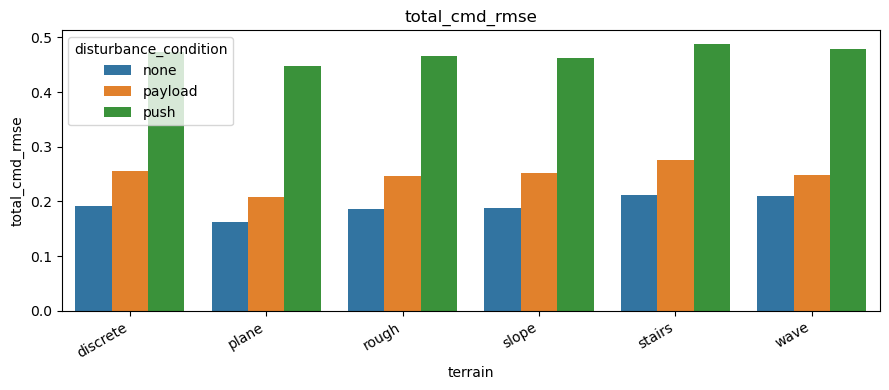

In [12]:
def plot_metric_by_terrain(results, metric, include_all=False):
    plot_df = results.copy()
    if not include_all:
        plot_df = plot_df[plot_df["terrain"] != "ALL"]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(9, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="disturbance_condition")
    else:
        for condition, group in plot_df.groupby("disturbance_condition"):
            plt.bar(group["terrain"], group[metric], label=condition)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_by_terrain(combined_results, "total_cmd_rmse")


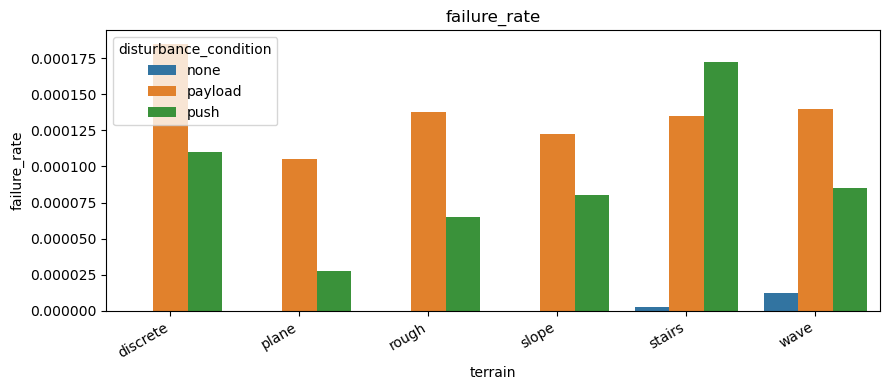

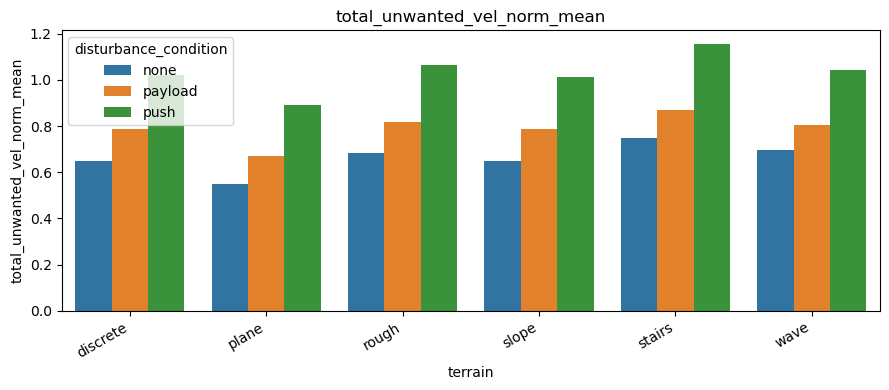

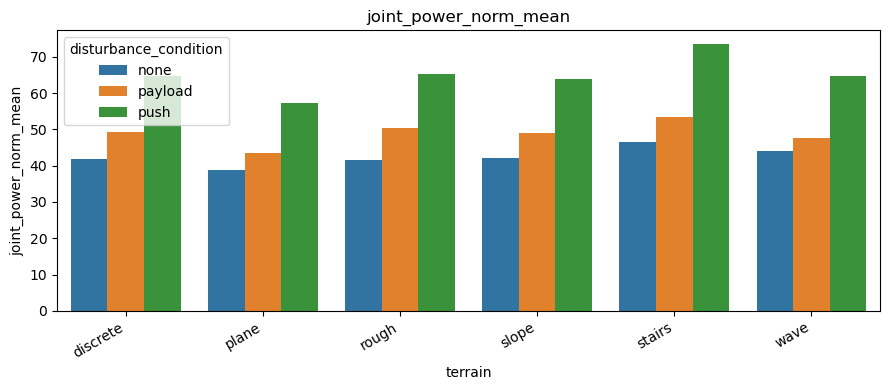

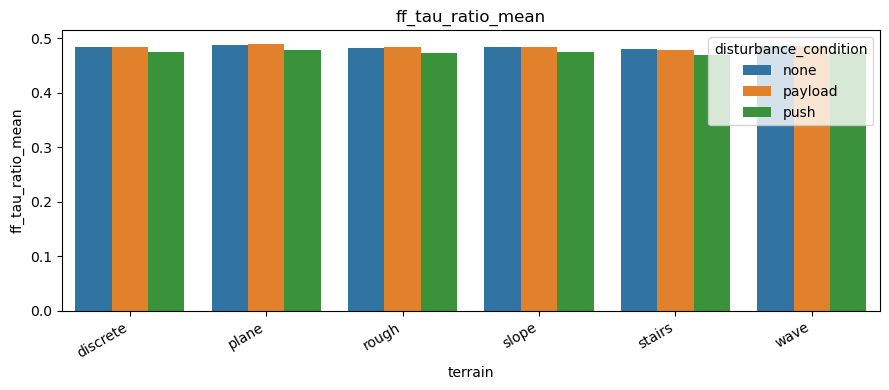

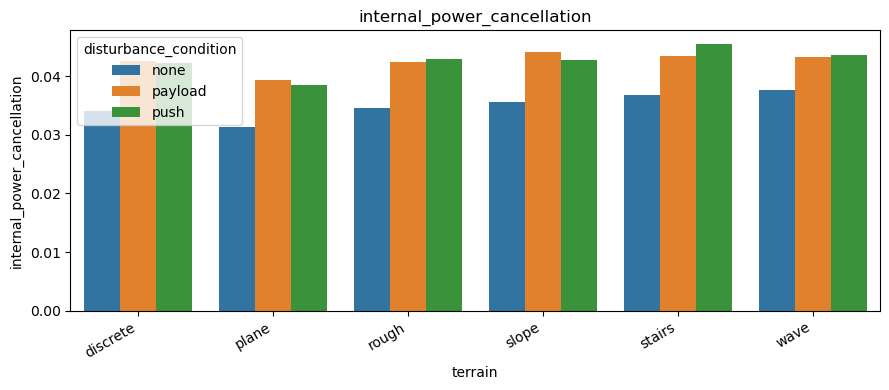

In [13]:
# Example additional plots
for metric in [
    "failure_rate",
    "total_unwanted_vel_norm_mean",
    "joint_power_norm_mean",
    "ff_tau_ratio_mean",
    "internal_power_cancellation",
]:
    if metric in combined_results.columns:
        plot_metric_by_terrain(combined_results, metric)


## Optional: compare multiple approaches

If you want to compare several approaches under the same experiment folder, set `APPROACHES` below and run the cell. It reuses the same functions above.


In [14]:
APPROACHES = ["pact"]  # e.g., ["pact", "pos", "tau"]

all_approach_dfs = []
for approach in APPROACHES:
    ft = find_eval_files(
        EXP_FOLDER,
        approach,
        disturbance_condition=DISTURBANCE_CONDITION,
    )
    if len(ft) == 0:
        print(f"No files found for approach: {approach}")
        continue

    all_approach_dfs.append(load_eval_dataset(ft))

if all_approach_dfs:
    df_multi = pd.concat(all_approach_dfs, ignore_index=True)

    multi_per_terrain = summarize_by_terrain(df_multi)
    multi_all_terrain = summarize_all_terrains(df_multi)
    multi_results = pd.concat([multi_per_terrain, multi_all_terrain], ignore_index=True)

    display(multi_results[[c for c in available_summary_cols if c in multi_results.columns]].round(4))
else:
    print("No approach files loaded.")


No files found for approach: pact
No approach files loaded.


In [15]:
def plot_metric_by_approach_and_terrain(results, metric, terrain_filter=None):
    plot_df = results.copy()

    if terrain_filter is not None:
        plot_df = plot_df[plot_df["terrain"].isin(terrain_filter)]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="approach")
    else:
        for approach, group in plot_df.groupby("approach"):
            plt.bar(group["terrain"], group[metric], label=approach)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "multi_results" in globals():
    plot_metric_by_approach_and_terrain(multi_results, "total_cmd_rmse")
